## Task 2 ==> Data Preprocessing

<div style="font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #be3125, #ba4c21);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2>🧹 Preprocessing Section</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="font-size:17px; color:#2c3e50;">
Data was cleaned, missing values handled, categorical features encoded, and numerical features scaled to prepare the dataset for modeling.
</p>

</div>

</div>

- Import The Libararies  

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import warnings; warnings.filterwarnings('ignore')

- Info about the data 

In [2]:
df = pd.read_csv('data.csv')
df.head()

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe


- Replacing the missing values in the gender column with forward fill method

In [3]:
df.info()
df['gender'] = df['gender'].replace("Other", np.nan)
df = df.fillna({'gender': df['gender'].ffill()})
df = df.dropna(subset=['gender'])
df = df.drop(columns=['id'])

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        5000 non-null   str    
 1   country                   5000 non-null   str    
 2   average_sunny_days        5000 non-null   int64  
 3   age                       5000 non-null   int64  
 4   gender                    5000 non-null   str    
 5   employment_status         5000 non-null   str    
 6   marital_status            5000 non-null   str    
 7   education_level           5000 non-null   str    
 8   monthly_income            5000 non-null   str    
 9   loneliness                3354 non-null   str    
 10  faith                     5000 non-null   bool   
 11  migration_background      5000 non-null   bool   
 12  overeating                5000 non-null   bool   
 13  physical_inactivity       5000 non-null   bool   
 14  high_sugar_intake  

In [4]:
df.head()

,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,faith,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
2,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,True,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,True,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,France,200,71,Male,Student,Married,Master,2000–3000€,Frequent,True,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe
5,Italy,230,78,Male,Employed,Divorced,Master,1000–2000€,NaN,True,...,True,True,True,True,False,True,Moderate,1.7,2.6,Mild
6,Sweden,170,45,Female,Student,Divorced,Bachelor,3000–5000€,NaN,True,...,True,False,False,False,False,True,Moderate,2.9,1.8,Mild


- Check the nulls 

In [5]:
print(df.isnull().sum())

country                        0
average_sunny_days             0
age                            0
gender                         0
employment_status              0
marital_status                 0
education_level                0
monthly_income                 0
loneliness                  1645
faith                          0
migration_background           0
overeating                     0
physical_inactivity            0
high_sugar_intake              0
energy_drink_consumption       0
high_coffee_consumption        0
ultra_processed_food           0
low_dietary_diversity          0
alcohol_consumption            0
smoking                        0
poor_sleep_quality             0
anxiety_level               1302
social_media_use_hours         0
news_hours_per_day             0
depression_severity            0
dtype: int64


- (Handle the Missing Values) ==> Fill the NA Values Because it has a large number or rows that contain NA 

In [6]:
# For Numeric 
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# For Cat
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

- After Handle the missing values 

In [7]:
print(df.isnull().sum())

country                        0
average_sunny_days             0
age                            0
gender                         0
employment_status              0
marital_status                 0
education_level                0
monthly_income                 0
loneliness                  1645
faith                          0
migration_background           0
overeating                     0
physical_inactivity            0
high_sugar_intake              0
energy_drink_consumption       0
high_coffee_consumption        0
ultra_processed_food           0
low_dietary_diversity          0
alcohol_consumption            0
smoking                        0
poor_sleep_quality             0
anxiety_level               1302
social_media_use_hours         0
news_hours_per_day             0
depression_severity            0
dtype: int64


- Before handling outliers (Boxplot)

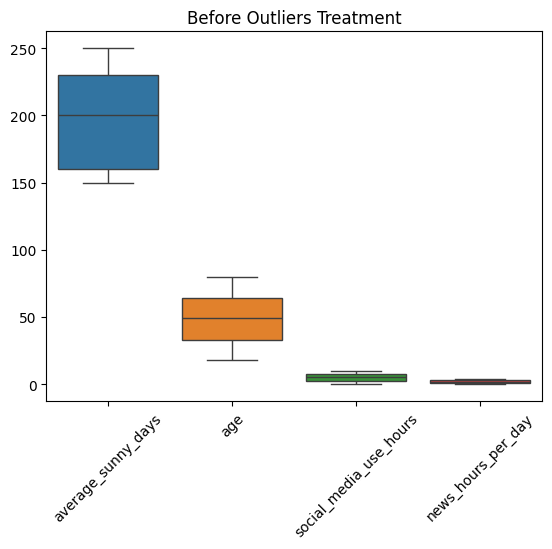

In [8]:
numeric_cols = df.select_dtypes(include='number').columns

sns.boxplot(data=df[numeric_cols])
plt.title("Before Outliers Treatment")
plt.xticks(rotation=45)
plt.show()

- There is no Outliers , So we don't have to remove it 

- Label Encoding the categorical features using mapping method

In [9]:
employment_map = {
    'Unemployed': 3,
    'Student': 2,
    'Retired': 1,
    'Employed': 0
}
marital_map = {
    'Single': 3,
    'Divorced': 2,
    'Widowed': 1,
    'Married': 0
}
education_map = {
    'High School': 3,
    'Bachelor': 2,
    'Master': 1,
    'PhD': 0
}
income_map = {
    '<1000': 4,
    '1000-2000': 3,
    '2000-3000': 2,
    '3000-5000': 1,
    '>5000': 0
}
loneliness_map = {
    'Frequent': 1,
    'Occasional': 0
}
anxiety_map = {
    'Severe': 2,
    'Moderate': 1,
    'Mild': 0
}
df['employment_status'] = df['employment_status'].map(employment_map)
df['marital_status'] = df['marital_status'].map(marital_map)
df['education_level'] = df['education_level'].map(education_map)
df['monthly_income'] = df['monthly_income'].map(income_map)
df['loneliness'] = df['loneliness'].map(loneliness_map)
df['anxiety_level'] = df['anxiety_level'].map(anxiety_map)


- Hot encoding the categorical data (country and gender)

In [10]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

- Split the data into features and target variable 

In [11]:
y = df['depression_severity']
df = df.drop(columns=['depression_severity'])

- Convert boolean columns to integers to prepare for standardization

In [12]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

- stander scaling the data for the variance to be 0 and the mean to be 0

In [ ]:
scaler = StandardScaler()


numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

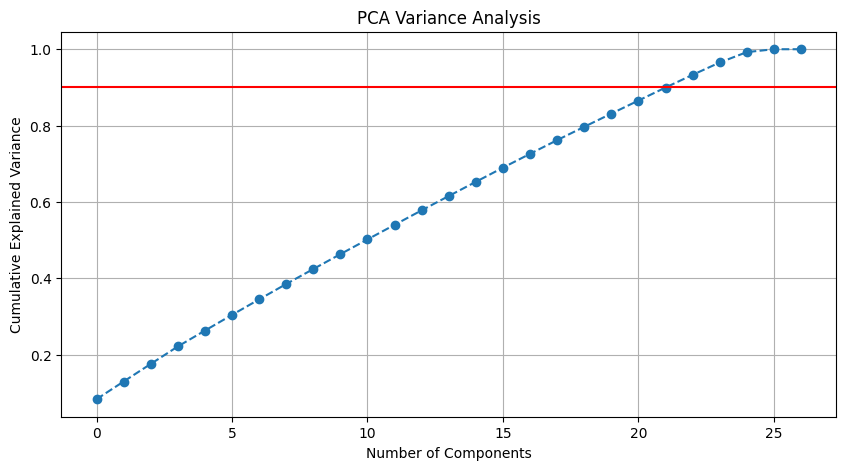

In [15]:
from sklearn.impute import SimpleImputer


numeric_df = df.select_dtypes(include=[np.number])


X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
# Impute missing values so PCA can run (PCA does not accept NaN)
imputer = SimpleImputer(strategy='median') ##
X_scaled = imputer.fit_transform(X_scaled)
pca.fit(X_scaled)


plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Analysis')
plt.axhline(y=0.90, color='r', linestyle='-') 
plt.grid()
plt.show()

pca_final = PCA(n_components=0.90)
X_pca = pca_final.fit_transform(X_scaled)

      

In [16]:
print(X_pca)

[[ 2.23627346  0.04440487  0.23668888 ... -0.19149472 -1.37737522
   1.10762058]
 [-1.03506555  1.76893785 -0.74668508 ... -1.5972168  -0.0720611
  -1.10356937]
 [ 0.08949476  0.14215871 -0.45172515 ...  0.33374585 -0.97852685
  -0.87887784]
 ...
 [-1.70339396 -0.165196    1.96504977 ...  1.61999402 -0.78336959
  -1.27056881]
 [-0.86938586  1.99578215 -0.61306229 ...  0.11968015  0.1138522
  -1.2032509 ]
 [-0.91872918  1.85890667 -0.1526385  ...  0.06637815  0.66438804
  -0.6680621 ]]


### PCA

- The blue curve shows cumulative explained variance vs number of principal components.
- The red horizontal line marks 90% explained variance; choose the smallest number of components where the curve crosses this line.
- `PCA(n_components=0.90)` automatically selects the minimum components that retain >= 90% of the variance.
- To see which number was chosen, run `print(pca_final.n_components_)` or check `X_pca.shape`.

Quick command to compute the crossing index manually:

`np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1`

## Hierarichal clustring

In [17]:
# some palletes to be used later
PALETTE  = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#F4A261', '#6A4C93']
LINK_CLR = {'ward': '#E63946', 'complete': '#2A9D8F', 'average': '#E9C46A'}

In [ ]:
class HierarchicalClustering:
    """
    hierarchical clustring class takes 2 parameters
    linkage_method: string takes values 'ward', 'complete', 'average', 'single'
    metric: string takes distance metric. 'euclidean' is required for ward 
    """

    def __init__(self, linkage_method='ward', metric='euclidean'):
        if linkage_method == 'ward' and metric != 'euclidean':
            raise ValueError("Ward linkage requires euclidean metric.")
        self.linkage_method = linkage_method
        self.metric         = metric
        self.Z_             = None # linkage matrix
        self.labels_        = None # cluster labels after prediction
        self.n_clusters_    = None # number of clusters after prediction


    def fit(self, X):
        self.X_ = X
        # compute linkage matrix
        self.Z_ = linkage(X, method=self.linkage_method, metric=self.metric)
        return self


    def predict(self, n_clusters):
        if self.Z_ is None:
            raise RuntimeError("call fit() first")
        self.n_clusters_ = n_clusters
        # assign cluster labels based on the linkage matrix and desired number of clusters
        self.labels_ = fcluster(self.Z_, t=n_clusters, criterion='maxclust')
        return self.labels_


    def plot_dendrogram(self, ax=None, title=None, truncate_mode='lastp', p=30):
        if self.Z_ is None:
            raise RuntimeError("you mustcall fit() first")
        # check if ax is provided for plotting if not, create a new figure and axis
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(12, 5))

        
        dendrogram(self.Z_, ax=ax,
                   truncate_mode=truncate_mode, p=p,
                   color_threshold=0.7 * max(self.Z_[:, 2]),
                   above_threshold_color='#AAAAAA',
                   leaf_rotation=90, leaf_font_size=8)

        ax.set_title(title or f"Dendrogram — {self.linkage_method.title()} Linkage",
                     fontsize=13, fontweight='bold')
        ax.set_xlabel("Sample index (or cluster size)")
        ax.set_ylabel("Distance")
        ax.spines[['top', 'right']].set_visible(False)

        if standalone:
            plt.tight_layout(); plt.show()


    def elbow_plot(self, max_k=10, ax=None):
        if self.Z_ is None:
            raise RuntimeError("Call fit() first.")
        # get the last max_k distances from the linkage matrix and reverse them
        last = self.Z_[-max_k:, 2][::-1]
        accel = np.diff(last, 2) # compute the second derivative of the distances
        k_range = range(1, max_k + 1) # k starts from 1 because the first merge happens at k=2 clusters
        color = LINK_CLR.get(self.linkage_method, '#333333')

        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(list(k_range), last, 'o-', color=color, linewidth=2, markersize=6)
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Merge Distance")
        ax.set_title(f"Elbow — {self.linkage_method.title()}", fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

        suggested_k = int(np.argmax(accel) + 2)
        ax.axvline(x=suggested_k, linestyle='--', color='red', alpha=0.7,
                   label=f"Suggested k={suggested_k}")
        ax.legend(fontsize=9)

        if standalone:
            plt.tight_layout(); plt.show()

        return suggested_k


    def silhouette_analysis(self, X, k_range=range(2, 9), ax=None):
        scores = {}
        # compute silhouette scores for each k in the specified range
        for k in k_range:
            lbl = fcluster(self.Z_, t=k, criterion='maxclust')
            scores[k] = silhouette_score(X, lbl)

        best_k = max(scores, key=scores.get)
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(8, 4))

        colors = [PALETTE[i % len(PALETTE)] for i in range(len(k_range))]
        ax.bar(list(scores.keys()), list(scores.values()),
               color=colors, edgecolor='white', linewidth=0.8)
        ax.bar(best_k, scores[best_k], color='crimson', edgecolor='white',
               label=f"Best k={best_k}  ({scores[best_k]:.3f})")
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Silhouette Score")
        ax.set_title(f"Silhouette — {self.linkage_method.title()}", fontweight='bold')
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

        if standalone:
            plt.tight_layout(); plt.show()

        print(f"  [{self.linkage_method.upper():8s}] "
              + "  ".join(f"k={k}: {v:.3f}" for k, v in scores.items()))
        print(f"  [{self.linkage_method.upper():8s}] Best k = {best_k}\n")
        return best_k, scores

  OPTIMAL CLUSTER ANALYSIS
  [WARD    ] k=2: 0.066  k=3: 0.084  k=4: 0.104  k=5: 0.104  k=6: 0.078  k=7: 0.064  k=8: 0.054
  [WARD    ] → Best k = 5

  WARD      elbow_k=6  silhouette_k=5  → using k=5
  [COMPLETE] k=2: 0.051  k=3: 0.065  k=4: 0.077  k=5: 0.087  k=6: 0.067  k=7: 0.058  k=8: 0.055
  [COMPLETE] → Best k = 5

  COMPLETE  elbow_k=2  silhouette_k=5  → using k=5
  [AVERAGE ] k=2: 0.066  k=3: 0.085  k=4: 0.105  k=5: 0.104  k=6: 0.078  k=7: 0.066  k=8: 0.054
  [AVERAGE ] → Best k = 4

  AVERAGE   elbow_k=6  silhouette_k=4  → using k=4


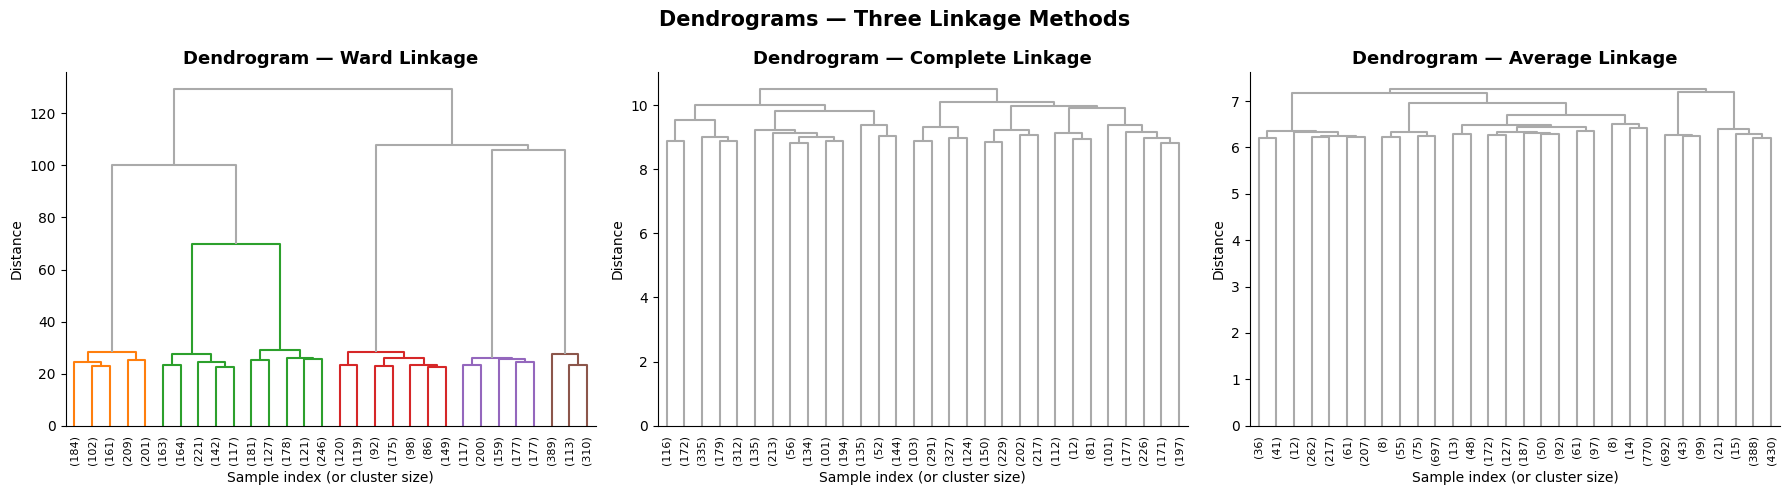

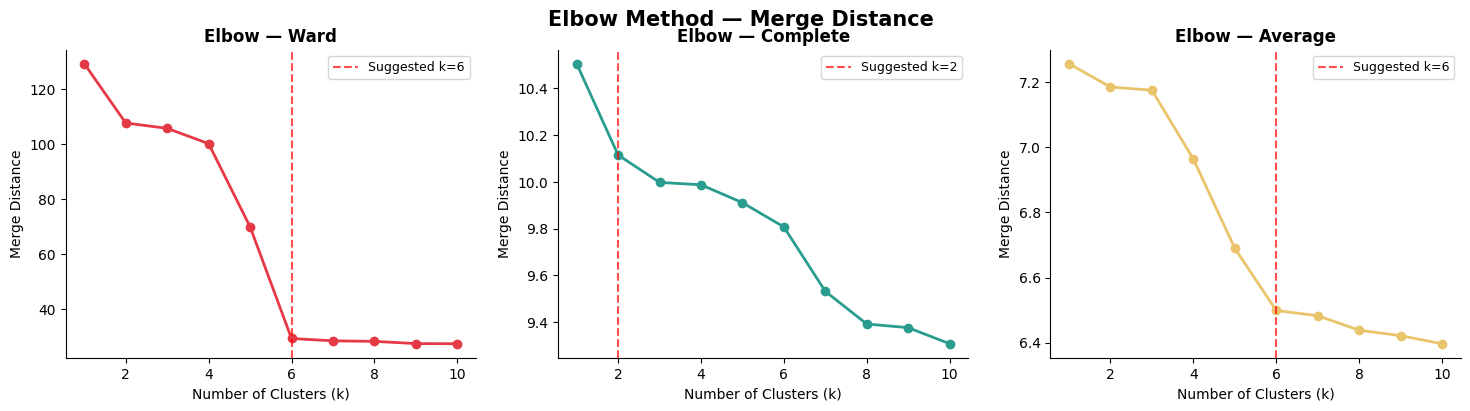

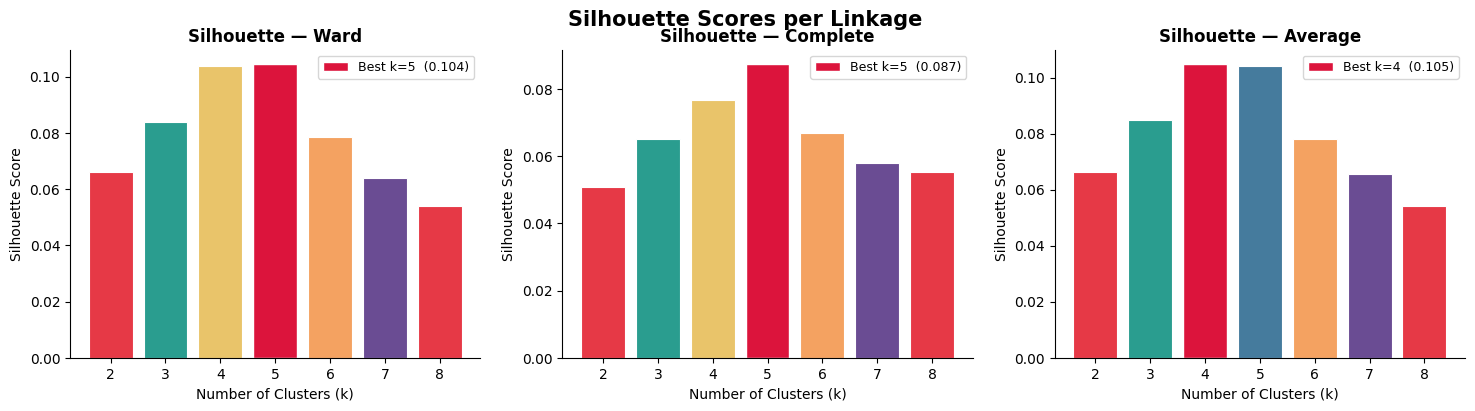

In [ ]:
methods = ['ward', 'complete', 'average']
results = {}
k_range = range(2, 9)

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Dendrograms — Three Linkage Methods", fontsize=15, fontweight='bold')

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
fig2.suptitle("Elbow Method — Merge Distance", fontsize=15, fontweight='bold')

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4))
fig3.suptitle("Silhouette Scores per Linkage", fontsize=15, fontweight='bold')

print("=" * 60)
print("optimal cluster analysis")
print("=" * 60)

for i, method in enumerate(methods):
    hc = HierarchicalClustering(linkage_method=method)
    hc.fit(X_pca)

    hc.plot_dendrogram(ax=axes1[i])
    elbow_k = hc.elbow_plot(max_k=10, ax=axes2[i])
    best_k, scores = hc.silhouette_analysis(X_pca, k_range=k_range, ax=axes3[i])

    final_k = best_k # silhouette is primary; use elbow as tiebreak
    labels  = hc.predict(final_k)

    results[method] = {"model": hc, "labels": labels,
                       "best_k": final_k, "scores": scores}
    print(f"  {method.upper():8s}  elbow_k={elbow_k}  silhouette_k={best_k}  → using k={final_k}")

print("=" * 60)

for fig in [fig1, fig2, fig3]:
    fig.tight_layout(); plt.show()

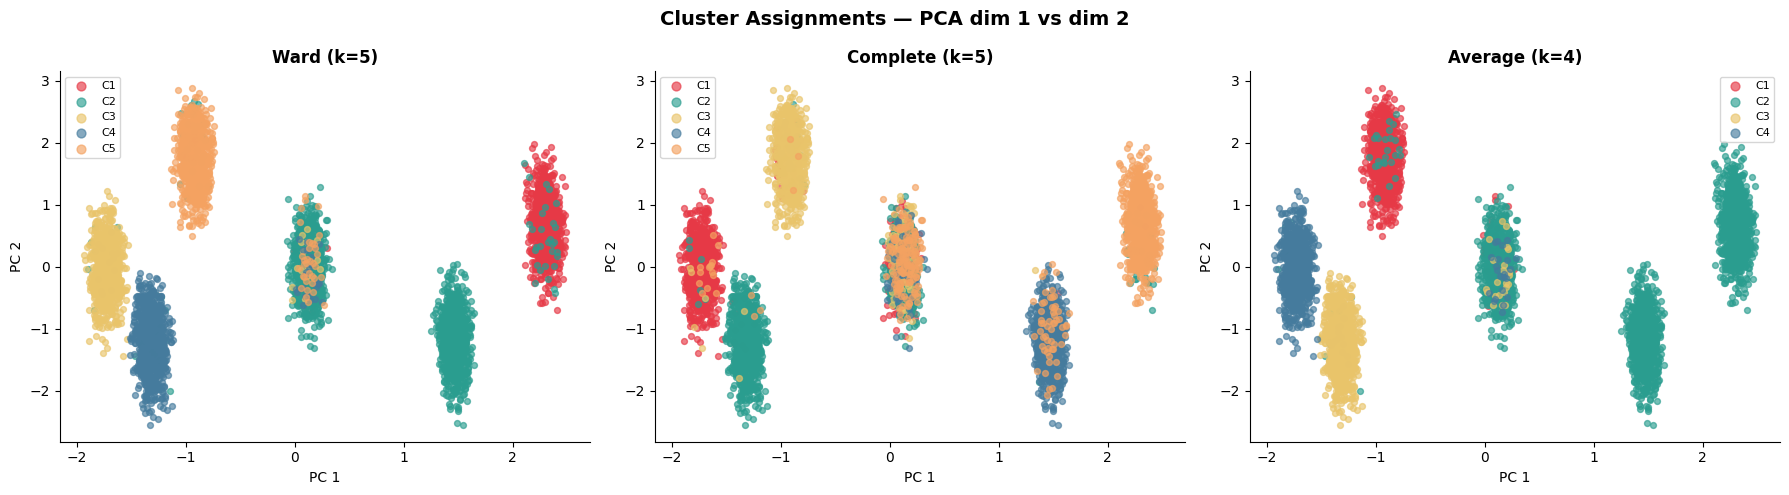

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Assignments — PCA dim 1 vs dim 2", fontsize=14, fontweight='bold')

for ax, (method, res) in zip(axes, results.items()):
    lbl, k = res['labels'], res['best_k']
    for c in np.unique(lbl):
        mask = lbl == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=18, alpha=0.65, label=f"C{c}",
                   color=PALETTE[(c - 1) % len(PALETTE)])
    ax.set_title(f"{method.title()} (k={k})", fontweight='bold')
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(markerscale=1.5, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

In [ ]:
#Build cluster profiles using Ward (best default method)
BEST_METHOD = 'ward'
res = results[BEST_METHOD]
hc = res['model'] 
labels = res['labels']
k = res['best_k']

profile_df  = df.copy()
profile_df['cluster'] = labels

dep_map = {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
profile_df['depression_severity'] = y.map(dep_map)

summary = profile_df.groupby('cluster').mean(numeric_only=True).round(3)
summary['cluster_size'] = profile_df.groupby('cluster').size()
print(summary.T)

cluster                         1         2        3        4        5
average_sunny_days          1.496     0.542   -1.152   -0.874   -0.602
age                        -0.052     0.011    0.006    0.019    0.008
employment_status          -0.025     0.000    0.040    0.019   -0.035
marital_status              0.011     0.004    0.036   -0.003   -0.055
education_level             0.012    -0.012    0.009   -0.034    0.037
monthly_income                NaN       NaN      NaN      NaN      NaN
loneliness                 -0.009     0.008    0.006   -0.003   -0.010
faith                       0.050    -0.053    0.041   -0.020    0.033
migration_background        0.008     0.007   -0.023   -0.027    0.029
overeating                 -0.003     0.039   -0.015   -0.020   -0.040
physical_inactivity         0.046     0.000   -0.020   -0.058    0.029
high_sugar_intake           0.046    -0.026   -0.005   -0.018    0.029
energy_drink_consumption    0.001    -0.003   -0.042    0.023    0.026
high_c

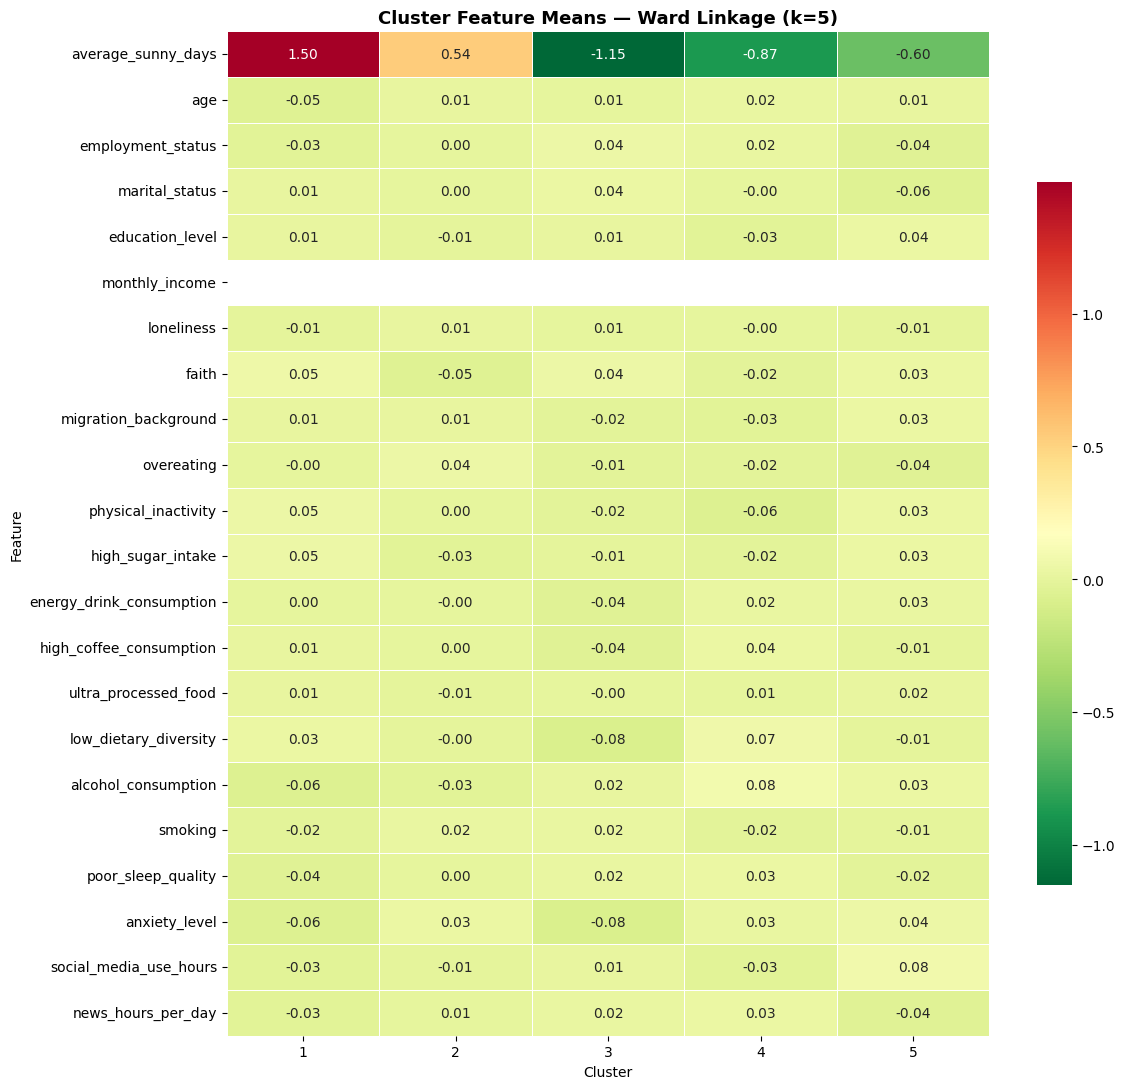

In [22]:
core_cols = [c for c in summary.columns
             if c not in ['depression_severity', 'cluster_size']
             and not c.startswith('country_')
             and not c.startswith('gender_')]

fig, ax = plt.subplots(figsize=(max(10, k * 2 + 2), 11))
sns.heatmap(summary[core_cols].T, annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title(f"Cluster Feature Means — {BEST_METHOD.title()} Linkage (k={k})",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()

In [26]:
decode = {
    'employment_status': {3: 'Unemployed', 2: 'Student', 1: 'Retired', 0: 'Employed'},
    'marital_status':    {3: 'Single', 2: 'Divorced', 1: 'Widowed', 0: 'Married'},
    'education_level':   {3: 'High School', 2: 'Bachelor', 1: 'Master', 0: 'PhD'},
    'monthly_income':    {4: '<1000', 3: '1000-2000', 2: '2000-3000',
                          1: '3000-5000', 0: '>5000'},
    'loneliness':        {1: 'Frequent', 0: 'Occasional'},
    'anxiety_level':     {2: 'Severe', 1: 'Moderate', 0: 'Mild'},
}

binary_lifestyle = [
    'overeating', 'physical_inactivity', 'high_sugar_intake',
    'energy_drink_consumption', 'high_coffee_consumption',
    'ultra_processed_food', 'low_dietary_diversity',
    'alcohol_consumption', 'smoking', 'poor_sleep_quality',
    'faith', 'migration_background'
]

dep_labels = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}

print("\n" + "=" * 70)
print(f"  CLUSTER INTERPRETATIONS  ({BEST_METHOD.upper()}, k={k})")
print("=" * 70)

for cid in sorted(summary.index):
    row  = summary.loc[cid]
    size = int(row.get('cluster_size', 0))
    dep  = row.get('depression_severity', float('nan'))

    print(f"\n{'─' * 70}")
    print(f"  CLUSTER {cid}  (n = {size})")
    print(f"{'─' * 70}")

    nearest_dep = min(dep_labels, key=lambda x: abs(x - dep))
    print(f"  Avg Depression Severity  : {dep_labels[nearest_dep]}  (mean={dep:.2f})")

    # demographics
    print("\n  DEMOGRAPHICS")
    for feat in ['age', 'employment_status', 'marital_status',
                 'education_level', 'monthly_income']:
        if feat not in row: continue
        val = row[feat]
        if feat in decode:
            nearest = min(decode[feat], key=lambda x: abs(x - val))
            print(f"    {feat:<22} ≈ {decode[feat][nearest]}  (mean={val:.2f})")
        else:
            print(f"    {feat:<22} = {val:.2f}")

    # lifestyle
    present = [f for f in binary_lifestyle if f in row and row[f] > 0.5]
    absent  = [f for f in binary_lifestyle if f in row and row[f] <= 0.5]
    print("\n  LIFESTYLE RISK FACTORS  (majority in cluster = mean > 0.5)")
    print(f"PRESENT: {', '.join(present) if present else 'None'}")
    print(f"ABSENT: {', '.join(absent)  if absent  else 'None'}")

    # mental / social
    print("\n  MENTAL HEALTH & SOCIAL BEHAVIOUR")
    for feat in ['loneliness', 'anxiety_level',
                 'social_media_use_hours', 'news_hours_per_day', 'average_sunny_days']:
        if feat not in row: continue
        val = row[feat]
        if feat in decode:
            nearest = min(decode[feat], key=lambda x: abs(x - val))
            print(f"    {feat:<26} ≈ {decode[feat][nearest]}  (mean={val:.2f})")
        else:
            print(f"    {feat:<26} = {val:.2f}")

    # heuristic label
    high_anxiety = row.get('anxiety_level', 0) > 0.8
    bad_sleep    = row.get('poor_sleep_quality', 0) > 0.5
    n_risks      = len(present)
    high_social  = row.get('social_media_use_hours', 0) > 6
    low_income   = row.get('monthly_income', 0) > 2.5
    unemployed   = row.get('employment_status', 0) > 2.5

    print("\n  CLUSTER LABEL")
    if high_anxiety and bad_sleep and n_risks >= 4:
        lbl = "HIGH-RISK: Severe psychosocial stress + multi-domain lifestyle impairment"
    elif high_anxiety and bad_sleep:
        lbl = "MODERATE-RISK: Anxious & sleep-deprived — candidate for mental health support"
    elif unemployed and low_income and n_risks >= 3:
        lbl = "SOCIOECONOMIC STRAIN: Financial vulnerability + sedentary unhealthy lifestyle"
    elif high_social and n_risks >= 2:
        lbl = "DIGITAL-DEPENDENT: Heavy social-media use, moderate mental health risk"
    elif n_risks <= 1 and not high_anxiety:
        lbl = "PROTECTIVE PROFILE: Few risk factors, good psychological indicators"
    else:
        lbl = "MIXED PROFILE: Moderate, heterogeneous risk — explore sub-clustering"

    print(f"{lbl}")



  CLUSTER INTERPRETATIONS  (WARD, k=5)

──────────────────────────────────────────────────────────────────────
  CLUSTER 1  (n = 857)
──────────────────────────────────────────────────────────────────────
  Avg Depression Severity  : Moderate  (mean=1.83)

  DEMOGRAPHICS
    age                    = -0.05
    employment_status      ≈ Employed  (mean=-0.03)
    marital_status         ≈ Married  (mean=0.01)
    education_level        ≈ PhD  (mean=0.01)
    monthly_income         ≈ <1000  (mean=nan)

  LIFESTYLE RISK FACTORS  (majority in cluster = mean > 0.5)
PRESENT: None
ABSENT: overeating, physical_inactivity, high_sugar_intake, energy_drink_consumption, high_coffee_consumption, ultra_processed_food, low_dietary_diversity, alcohol_consumption, smoking, poor_sleep_quality, faith, migration_background

  MENTAL HEALTH & SOCIAL BEHAVIOUR
    loneliness                 ≈ Occasional  (mean=-0.01)
    anxiety_level              ≈ Mild  (mean=-0.06)
    social_media_use_hours     = -0.03
  